In [1]:

# Install ultralytics
!pip install ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 141.9 MB/s eta 0:00:00


In [2]:
import zipfile
import os

ZIP_FILE = "/content/Bowling Pin Detection.v1i.yolov8.zip"
EXTRACT_TO = "/content/pin-bowling-2"

# Create output folder
os.makedirs(EXTRACT_TO, exist_ok=True)

# Extract zip
with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_TO)

print(f"Extracted to: {EXTRACT_TO}")

# Show extracted files
print(os.listdir(EXTRACT_TO))

Extracted to: /content/pin-bowling-2
['README.dataset.txt', 'train', 'test', 'README.roboflow.txt', 'valid', 'data.yaml']


In [6]:
cat {EXTRACT_TO}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['pin']

roboflow:
  workspace: mahmouds-workspace-bbq8o
  project: bowling-pin-detection-fbnbe
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/mahmouds-workspace-bbq8o/bowling-pin-detection-fbnbe/dataset/1

In [7]:
from ultralytics import YOLO

# Load pretrained YOLO11m
model = YOLO("yolo11m.pt")

# Train on your bowling pin dataset
results = model.train(
    data=f"{EXTRACT_TO}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    optimizer="AdamW",
    lr0=0.001,
    augment=True,
    device=0,          # GPU
    project="bowling_training",
    name="bowling_pins",
    exist_ok=True,
    verbose=True,
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pin-bowling-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, im

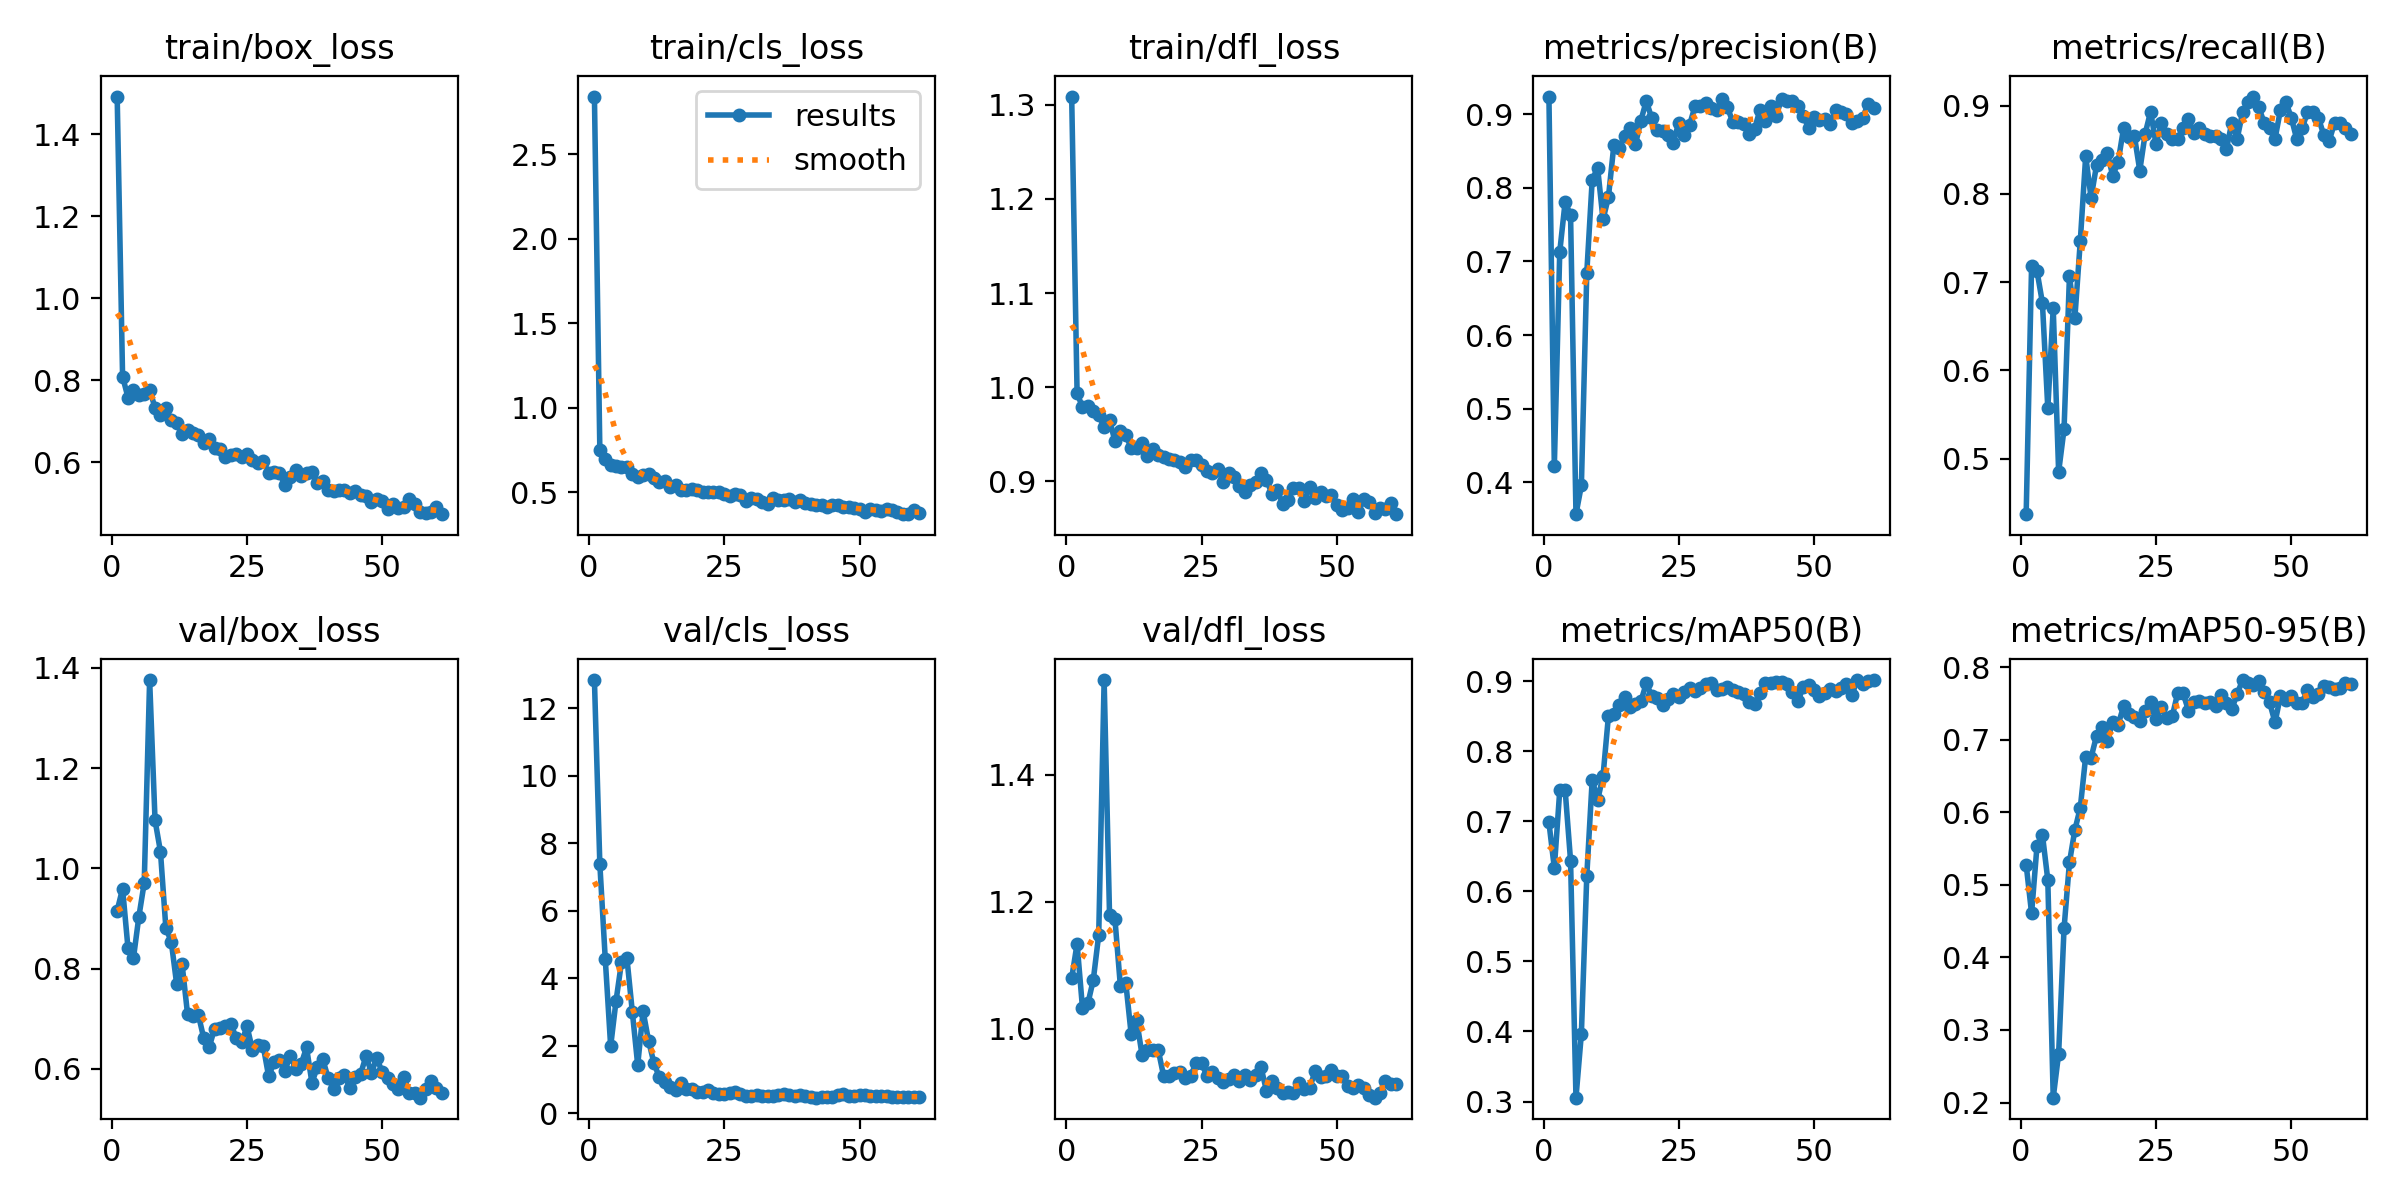

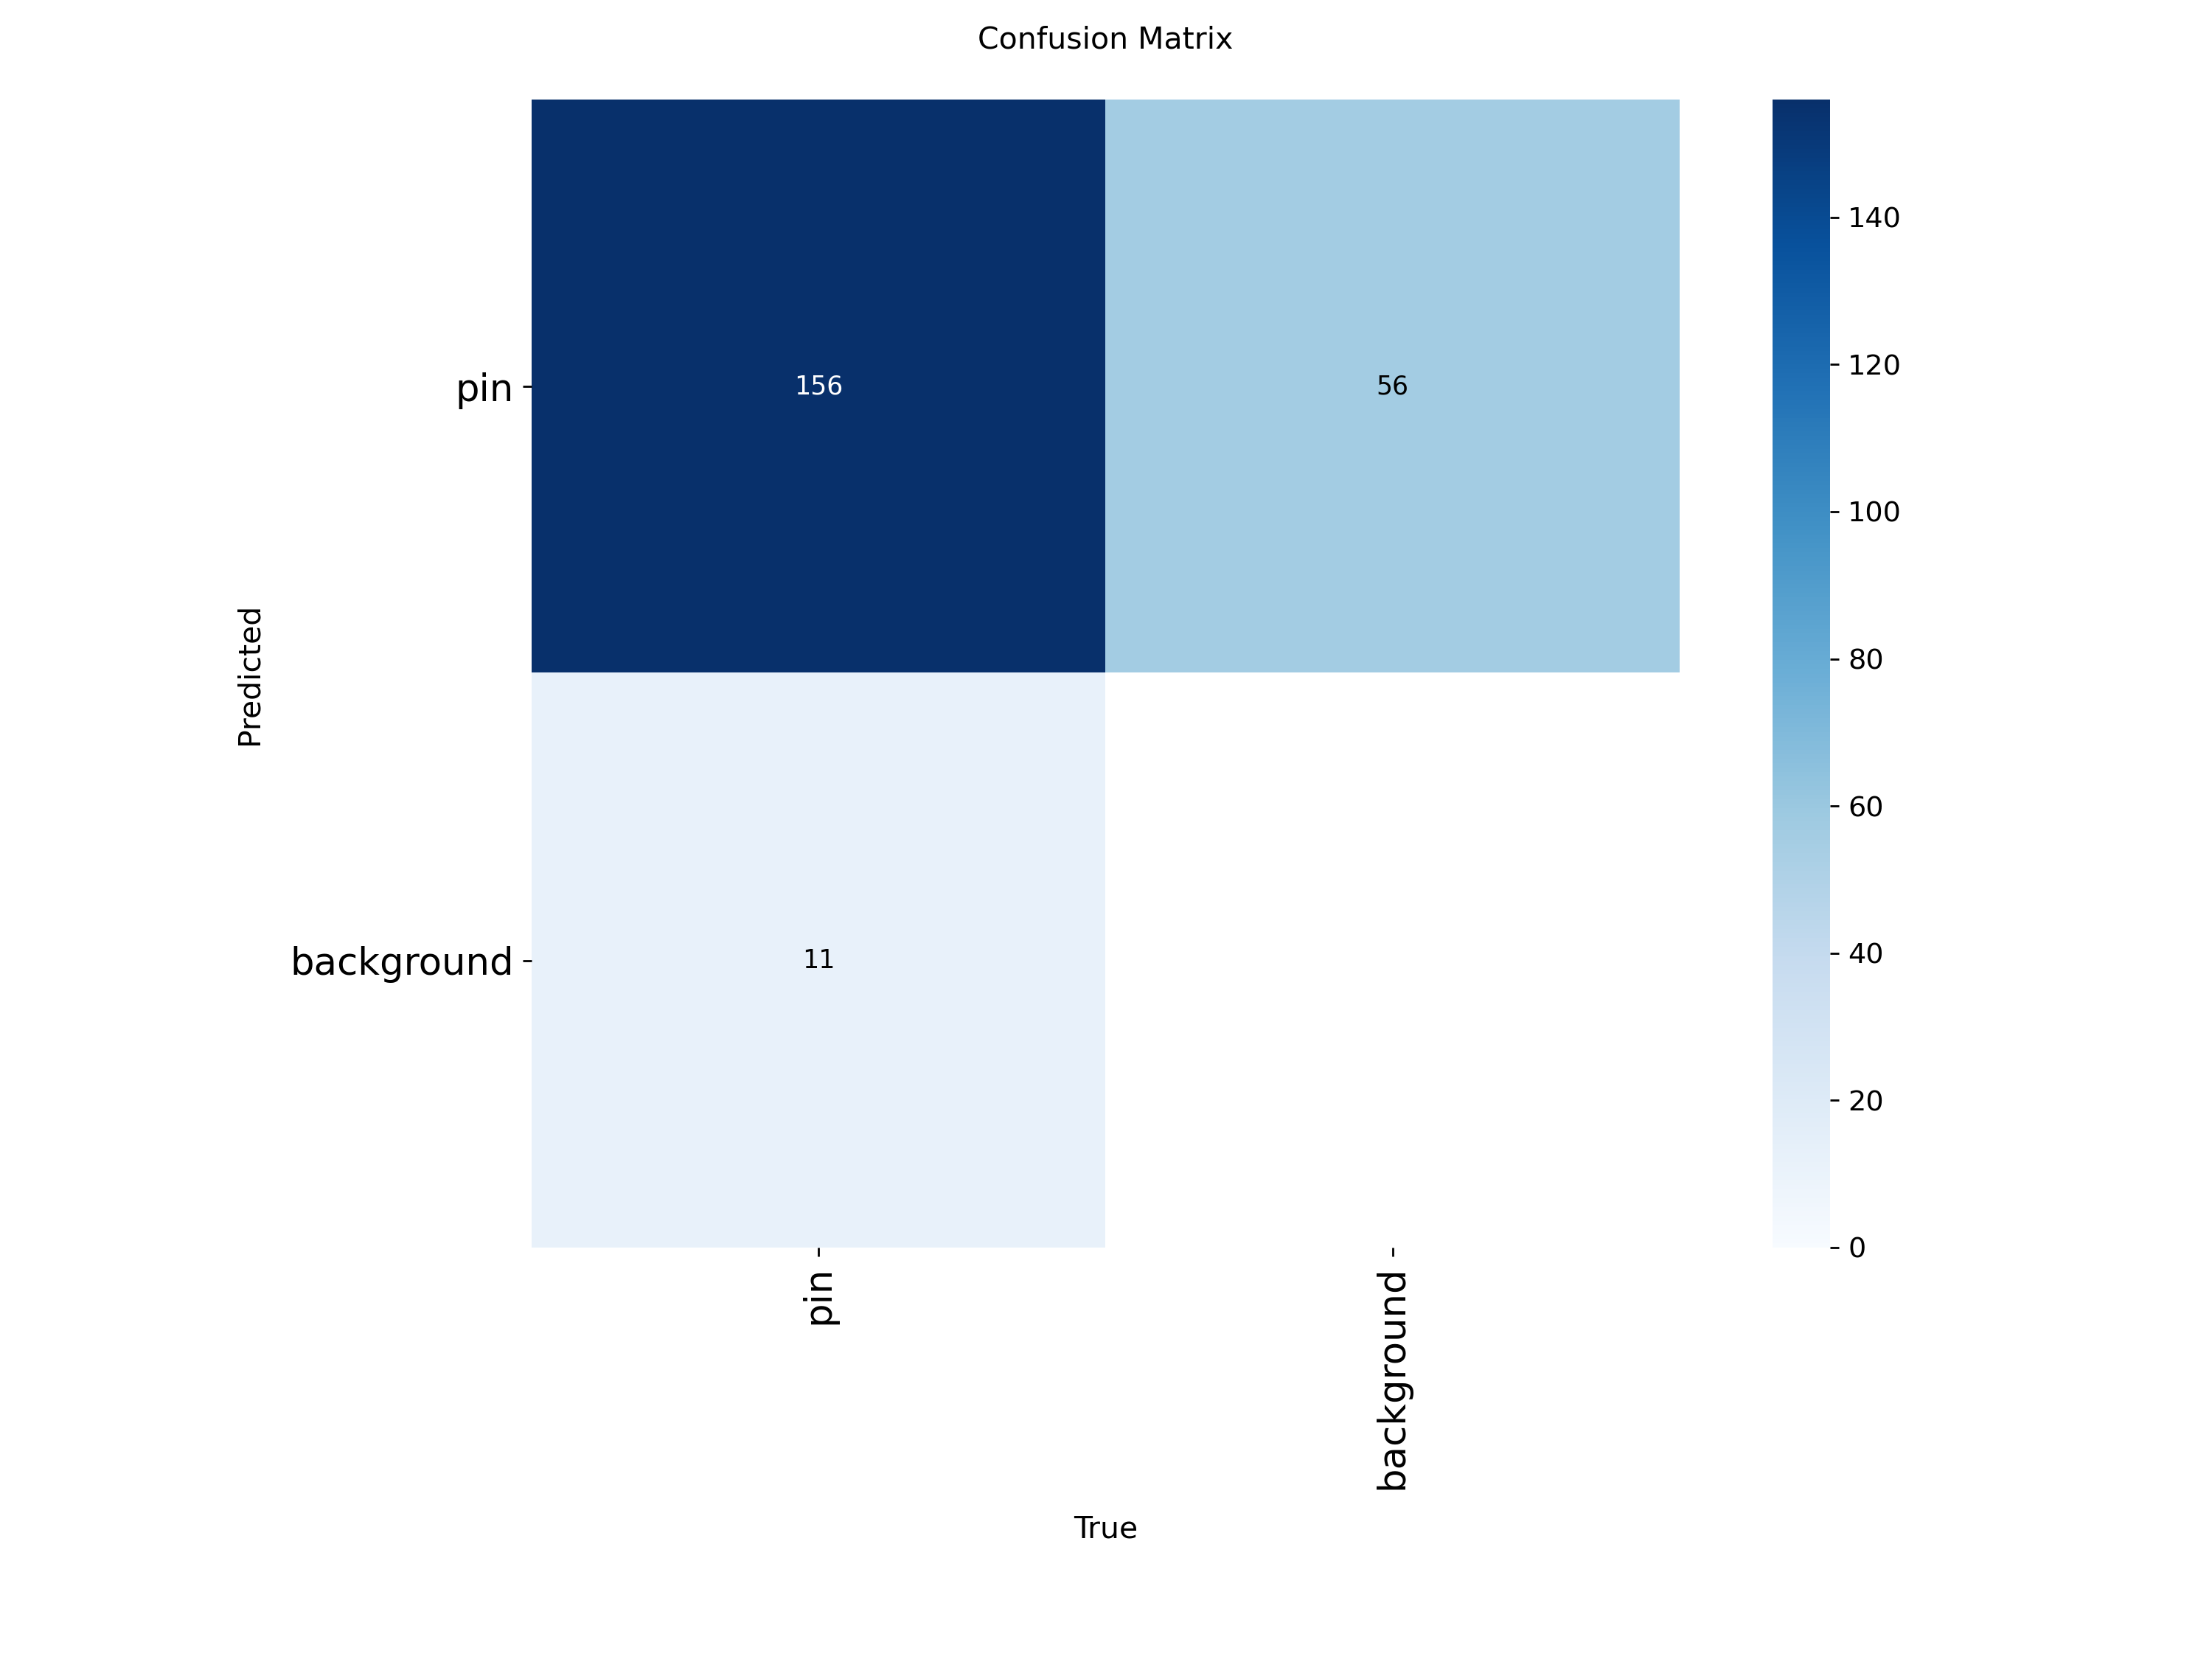

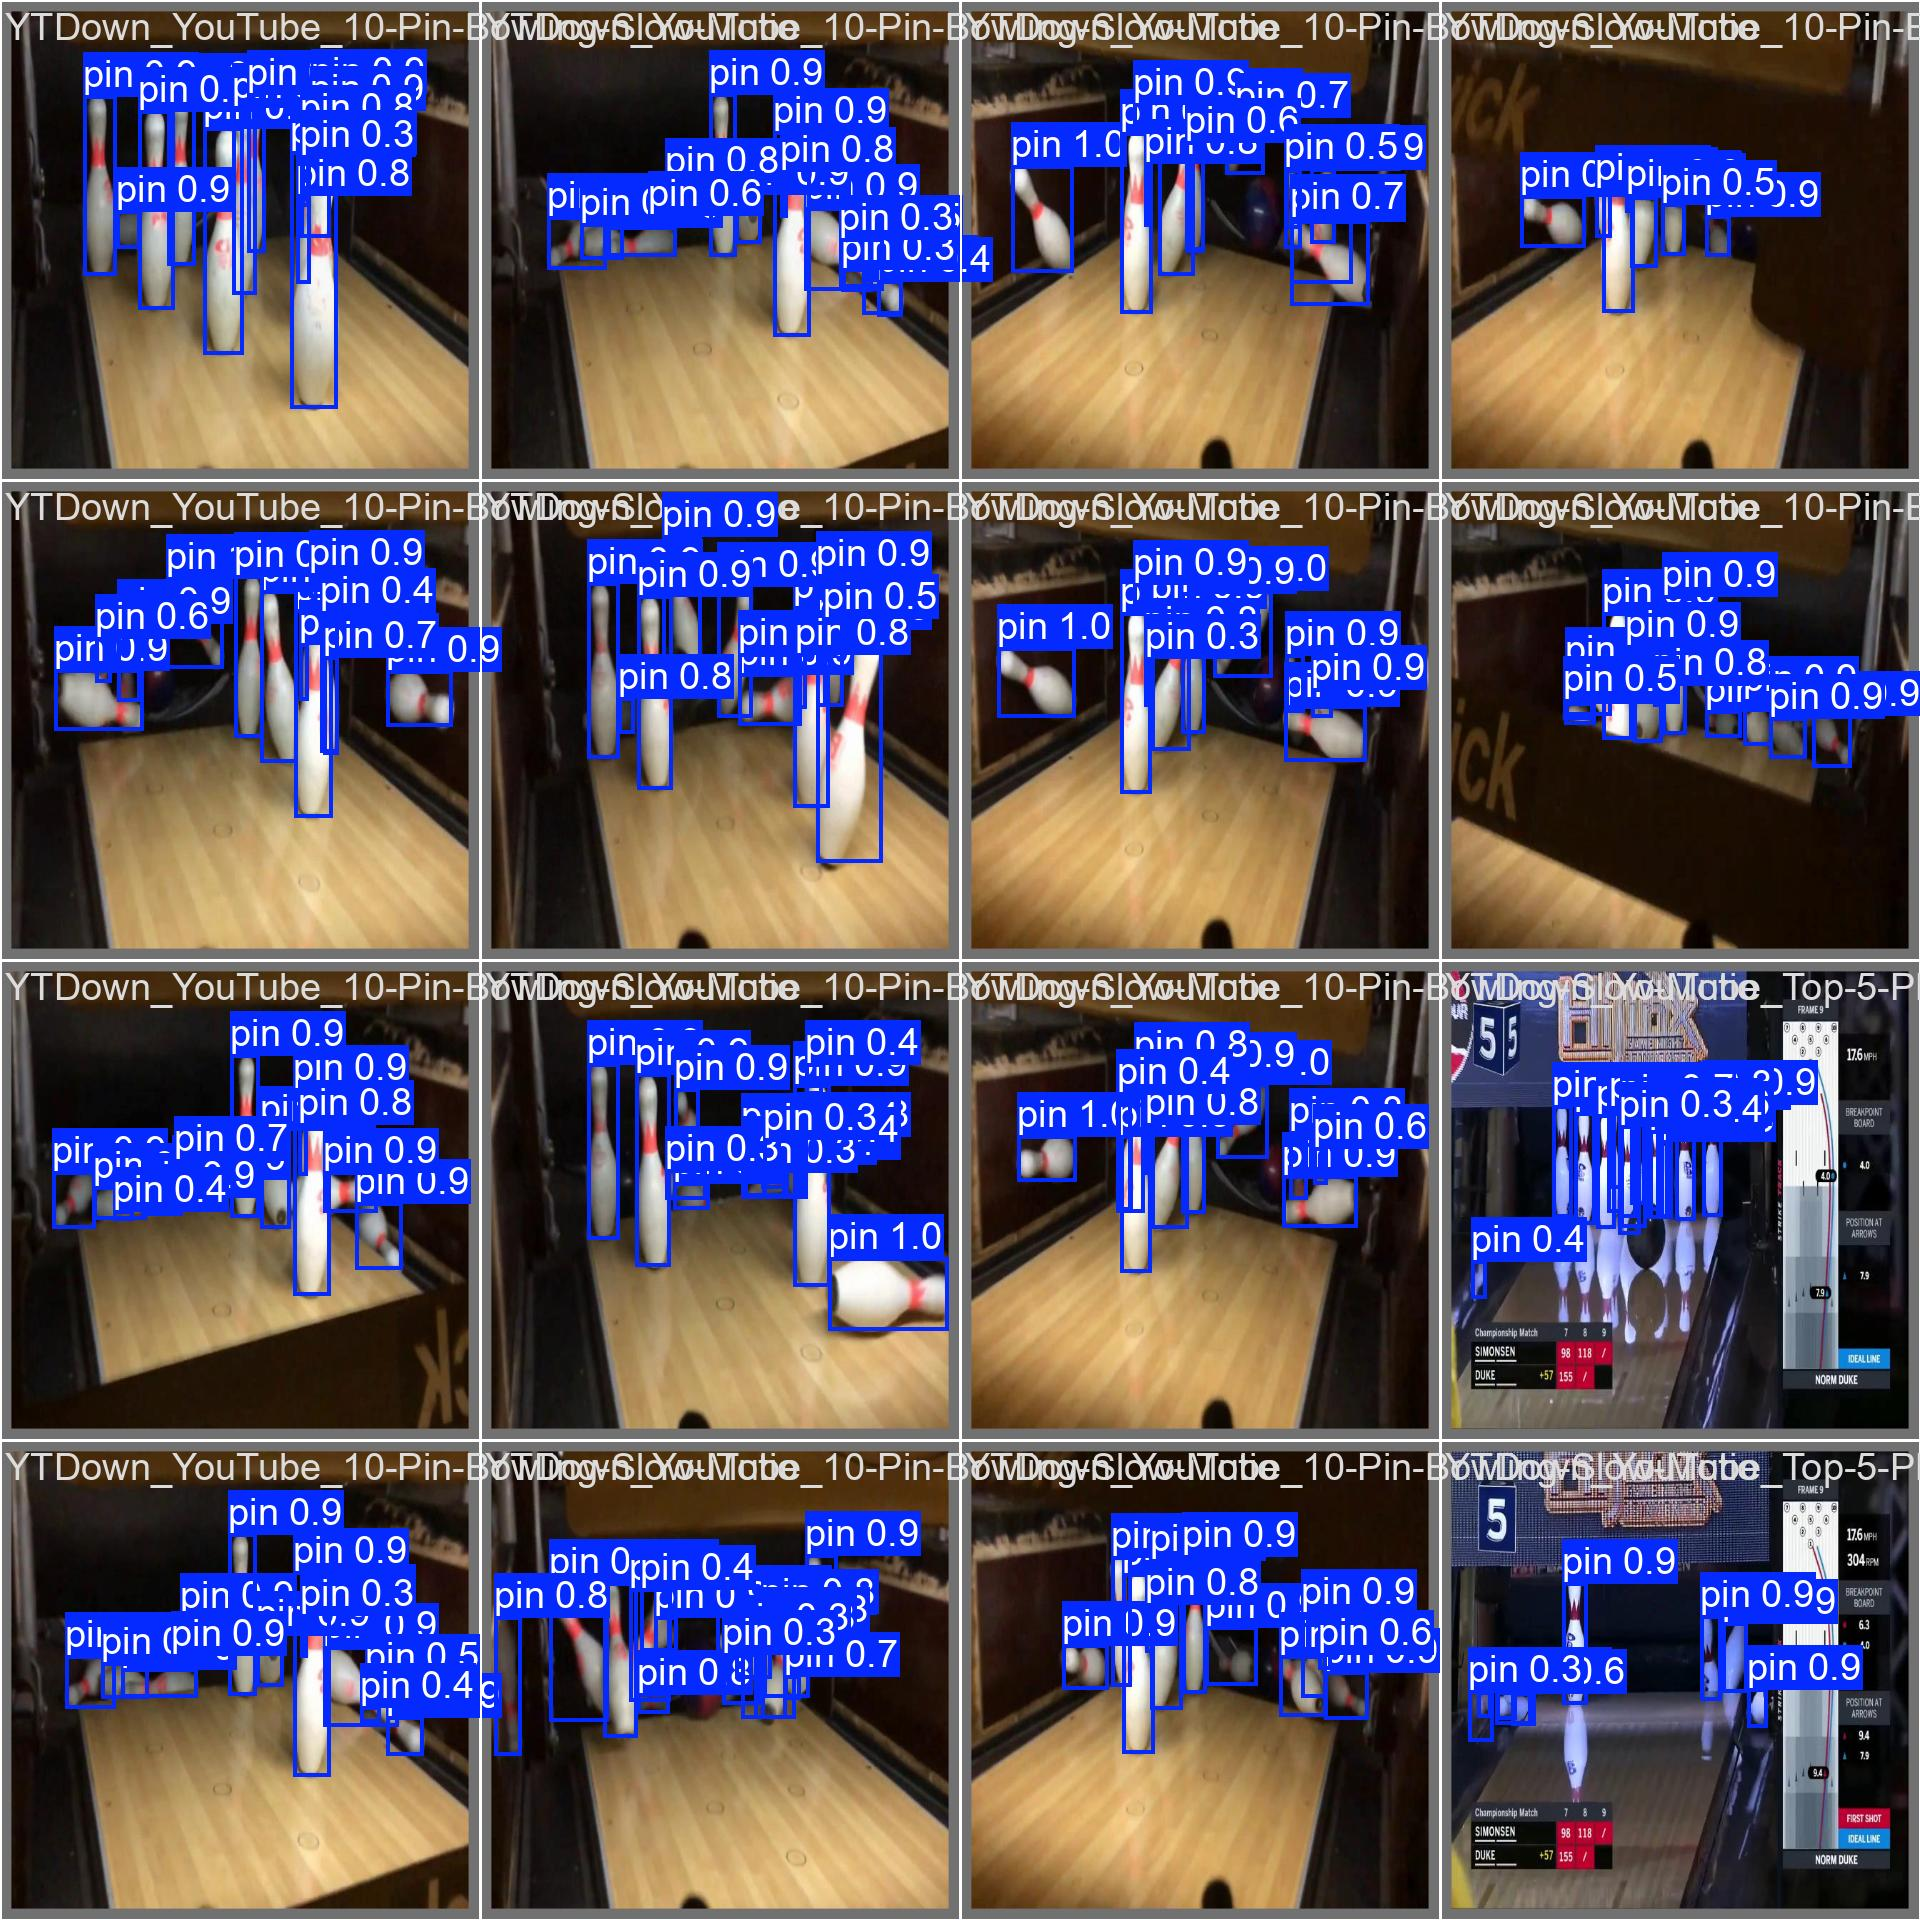

In [9]:
from IPython.display import Image, display
import os

# The actual path where YOLO saved the results
RESULTS_DIR = "/content/runs/detect/bowling_training/bowling_pins"

# Show training curves
display(Image(filename=f"{RESULTS_DIR}/results.png", width=800))

# Show confusion matrix
display(Image(filename=f"{RESULTS_DIR}/confusion_matrix.png", width=600))

# Show validation predictions
display(Image(filename=f"{RESULTS_DIR}/val_batch0_pred.jpg", width=800))

In [11]:
# Run evaluation on test split
# Fixed the path to include 'runs/detect/' and used 'EXTRACT_TO' for the data path
model = YOLO("/content/runs/detect/bowling_training/bowling_pins/weights/best.pt")
metrics = model.val(data=f"{EXTRACT_TO}/data.yaml", split="test")

print(f"\nmAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 42.7±77.5 MB/s, size: 27.4 KB)
val: Scanning /content/pin-bowling-2/test/labels... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 259.8it/s 0.0s
val: /content/pin-bowling-2/test/images/YTDown_YouTube_10-Pin-Bowling-Slow-Motion-Pin-Action_Media_Y0BmYAwzWoY_001_720p_frame_000450_png.rf.2583a35c5937bc0eb92dbb9619bc1c40.jpg: 1 duplicate labels removed
val: New cache created: /content/pin-bowling-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.7it/s 0.4s
                   all          8         90      0.821      0.833      0.839      0.699
Speed: 2.0ms preprocess, 34.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val

mAP50:    0.8394

In [13]:
from google.colab import files

# Download best weights using the correct RESULTS_DIR path
files.download(f"{RESULTS_DIR}/weights/best.pt")

# Optionally also download last.pt (for resuming training later)
# files.download(f"{RESULTS_DIR}/weights/last.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>